In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv(r"C:\Users\Welcome\Downloads\Indian_Kids_Screen_Time.csv")

In [12]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


In [13]:
df.shape

(9712, 8)

In [14]:
df.head(5)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [16]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [17]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [18]:
from sklearn.preprocessing import MultiLabelBinarizer

# Handle missing values
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')

# Convert to list
df['Health_Impacts'] = df['Health_Impacts'].str.split(', ')

# Encode
mlb = MultiLabelBinarizer()
health_encoded = pd.DataFrame(
    mlb.fit_transform(df['Health_Impacts']),
    columns=mlb.classes_,
    index=df.index
)

# Merge back
df = pd.concat([df, health_encoded], axis=1)

# Count health issues
df['Health_Issue_Count'] = df['Health_Impacts'].apply(len)

print(df.head())


   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

             Health_Impacts Urban_or_Rural  Anxiety  Eye Strain  None  \
0  [Poor Sleep, Eye Strain]          Urban        0           1     0   
1              [Poor Sleep]          Urban        0           0     0   
2              [P

In [19]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Anxiety,Eye Strain,None,Obesity Risk,Poor Sleep,Health_Issue_Count
0,14,Male,3.99,Smartphone,True,0.42,"[Poor Sleep, Eye Strain]",Urban,0,1,0,0,1,2
1,11,Female,4.61,Laptop,True,0.30,[Poor Sleep],Urban,0,0,0,0,1,1
2,18,Female,3.73,TV,True,0.32,[Poor Sleep],Urban,0,0,0,0,1,1
3,15,Female,1.21,Laptop,False,0.39,[None],Urban,0,0,1,0,0,1
4,12,Female,5.89,Smartphone,True,0.49,"[Poor Sleep, Anxiety]",Urban,1,0,0,0,1,2


In [20]:
percent_exceeded = df['Exceeded_Recommended_Limit'].mean() * 100

In [21]:
percent_exceeded

np.float64(85.47158154859967)

In [22]:
device_counts = df['Primary_Device'].value_counts()

In [23]:
device_counts

Primary_Device
Smartphone    4568
TV            2487
Laptop        1433
Tablet        1224
Name: count, dtype: int64

In [24]:
urban_rural_avg = df.groupby('Urban_or_Rural')['Avg_Daily_Screen_Time_hr'].mean()

In [25]:
urban_rural_avg

Urban_or_Rural
Rural    4.373702
Urban    4.344123
Name: Avg_Daily_Screen_Time_hr, dtype: float64

In [26]:
gender_avg = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()

In [27]:
gender_avg

Gender
Female    4.327021
Male      4.377754
Name: Avg_Daily_Screen_Time_hr, dtype: float64

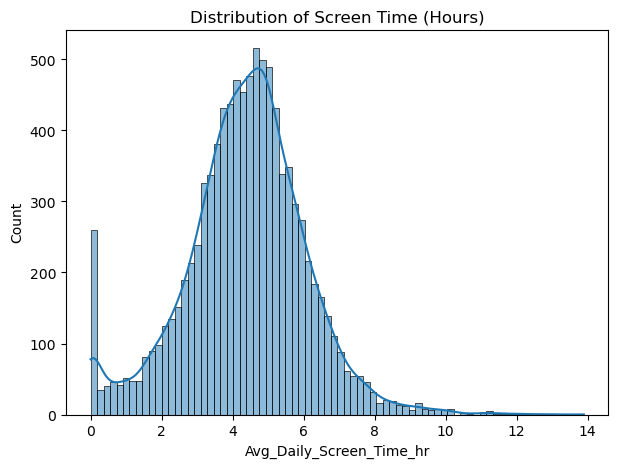

In [28]:
plt.figure(figsize=(7,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], kde=True)
plt.title("Distribution of Screen Time (Hours)")
plt.show()




# Device usage

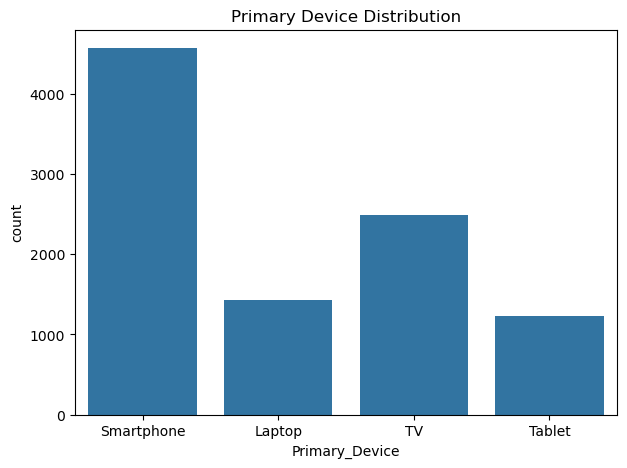

In [29]:
plt.figure(figsize=(7,5))
sns.countplot(x=df['Primary_Device'])
plt.title("Primary Device Distribution")
plt.show()

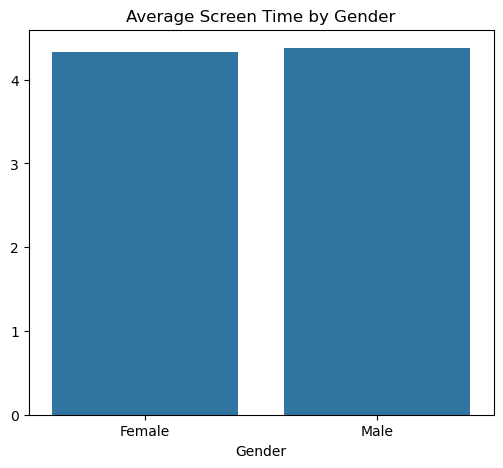

In [30]:
plt.figure(figsize=(6,5))
sns.barplot(x=gender_avg.index, y=gender_avg.values)
plt.title("Average Screen Time by Gender")
plt.show()

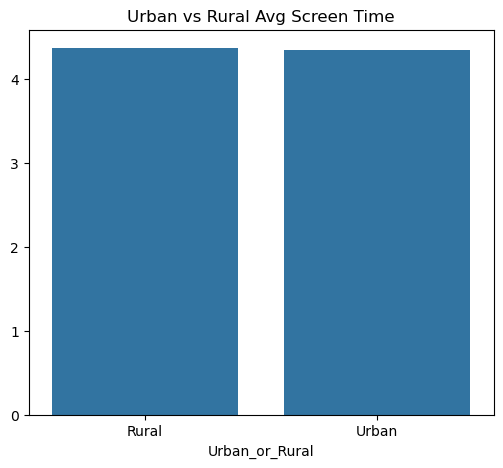

In [31]:
plt.figure(figsize=(6,5))
sns.barplot(x=urban_rural_avg.index, y=urban_rural_avg.values)
plt.title("Urban vs Rural Avg Screen Time")
plt.show()

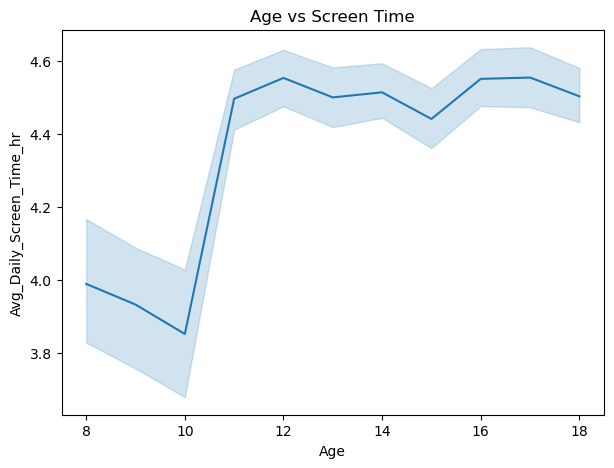

In [32]:
plt.figure(figsize=(7,5))
sns.lineplot(data=df, x='Age', y='Avg_Daily_Screen_Time_hr')
plt.title("Age vs Screen Time")
plt.show()


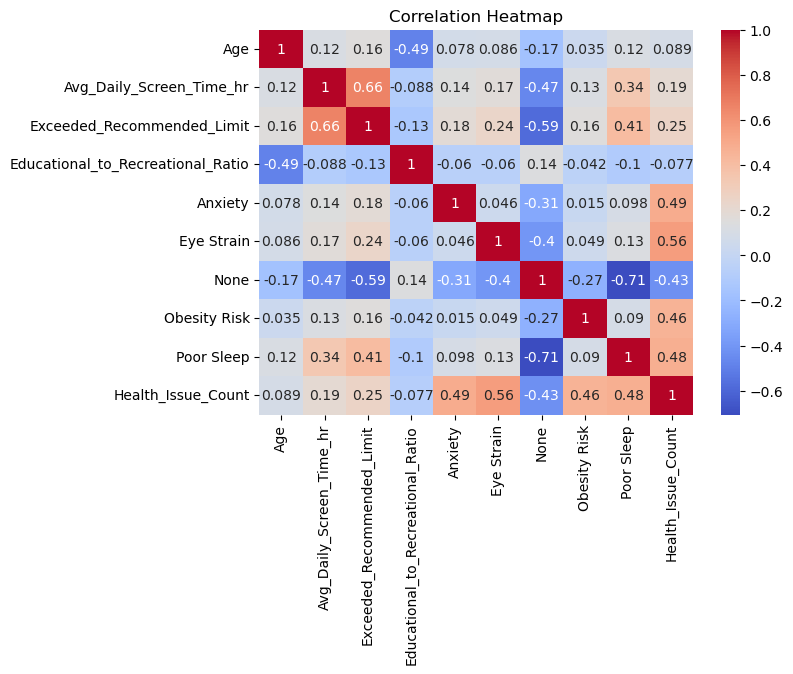

In [33]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

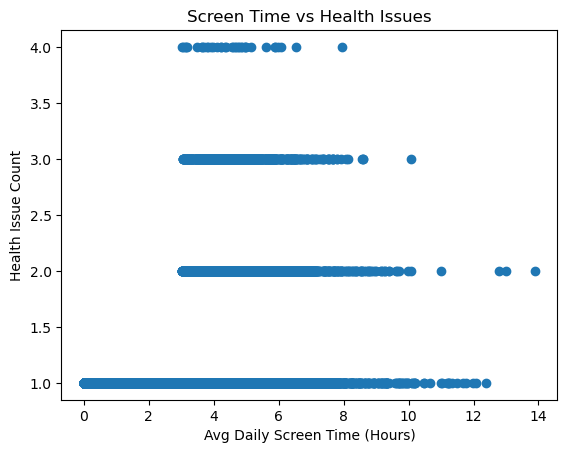

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['Avg_Daily_Screen_Time_hr'], df['Health_Issue_Count'])
plt.title("Screen Time vs Health Issues")
plt.xlabel("Avg Daily Screen Time (Hours)")
plt.ylabel("Health Issue Count")
plt.show()


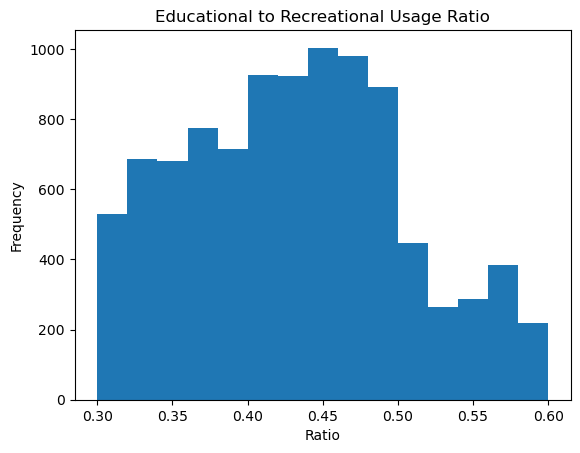

In [35]:
plt.figure()
plt.hist(df['Educational_to_Recreational_Ratio'], bins=15)
plt.title("Educational to Recreational Usage Ratio")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()


In [37]:
df.to_csv(r"C:\Users\Welcome\Pictures\Camera Roll\cleaned_data.csv",index=False)